<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/akshyat_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2.3 Monolingual vs. Multilingual — Sarcasm Detection
## COM3029 Group Coursework · BESSTIE Dataset

### Research Question
**Does a multilingual model (XLM-RoBERTa-base), pre-trained on 100+ languages, handle code-mixed Indian English (en-IN) better than a monolingual English model (RoBERTa-base) for the Sarcasm Detection task?**

### Hypothesis
XLM-RoBERTa will demonstrate a measurable advantage on the **en-IN** test split, where code-switching with Hindi vocabulary (e.g., *"yaar"*, *"chori"*, *"zyada"*, *"bilkul"*, *"coz"*) is common.  
RoBERTa's English-only BPE tokenizer will fragment Hindi words into semantically opaque sub-tokens, whereas XLM-RoBERTa's multilingual SentencePiece vocabulary provides better coverage.  
For **Inner-Circle** varieties (en-AU, en-UK) the difference is expected to be smaller.

### Experimental Setup

| | Monolingual | Multilingual |
|---|---|---|
| **Model** | `roberta-base` | `xlm-roberta-base` |
| **Pre-training** | English only (~160 GB) | 100+ languages (2.5 TB) |
| **Tokenizer** | Byte-Pair Encoding (English) | SentencePiece (multilingual) |
| **Parameters** | ~125 M | ~270 M |
| **Task** | Sarcasm Detection (Binary) | Sarcasm Detection (Binary) |
| **Training data** | Combined train: en-AU + en-IN + en-UK | Same |
| **Seeds** | 42, 123 (2 runs) | 42, 123 (2 runs) |

**Class Imbalance Mitigation:** Sarcasm is naturally rare; we use **class-weighted cross-entropy** to prevent the model from predicting "Not Sarcastic" for everything.


In [1]:
!pip install transformers datasets scikit-learn torch matplotlib seaborn pandas numpy tqdm evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00


In [2]:
import os, gc, time, warnings, random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, concatenate_datasets, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding, set_seed
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [3]:
TASK               = "sarcasm"
VARIETIES          = ["en-AU", "en-IN", "en-UK"]
DATASET_NAME       = "surrey-nlp/BESSTIE-CW-26"
OUTPUT_DIR         = "./outputs_2_3"

MONOLINGUAL_MODEL  = "roberta-base"
MULTILINGUAL_MODEL = "xlm-roberta-base"
SEEDS              = [42, 123]

MAX_LEN       = 128
BATCH_SIZE    = 16
EPOCHS        = 5
LR            = 2e-5
WARMUP_RATIO  = 0.1
WEIGHT_DECAY  = 0.01

LABEL_NAMES = ["Not Sarcastic", "Sarcastic"] if TASK == "sarcasm" else ["Negative", "Positive"]

os.makedirs(OUTPUT_DIR, exist_ok=True)


## 1. Data Loading
Load the BESSTIE dataset from HuggingFace. The dataset provides per-variety configs with Train / Validation / Test splits.


In [4]:
ds = load_dataset(DATASET_NAME)

# Split into per-variety dicts
raw = {}
for variety in VARIETIES:
    raw[variety] = DatasetDict({
        split: ds[split].filter(lambda x: x["variety"] == variety)
        for split in ds.keys()
    })

print("Sample row:", dict(raw["en-AU"]["train"][0]))


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/2183 [00:00<?, ? examples/s]

Filter:   0%|          | 0/3747 [00:00<?, ? examples/s]

Filter:   0%|          | 0/313 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2183 [00:00<?, ? examples/s]

Sample row: {'text': 'Yeah it blew out to 3x what it was budgeted for. Who wouldve thought giving people free cash to reovate their house would dry up resources for new builds...', 'variety': 'en-AU', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 1.0}


In [5]:
rows = []
for variety in VARIETIES:
    for split in ["train", "validation", "test"]:
        if split not in raw[variety]:
            continue
        d = raw[variety][split]
        n = len(d)
        label_col = next(
            (c for c in [TASK.capitalize(), f"{TASK}_label", TASK, "label"]
             if c in d.features), None
        )
        if label_col:
            labels = [int(x) for x in d[label_col]]
            c1, c0 = sum(labels), n - sum(labels)
        else:
            c0 = c1 = -1
        rows.append({
            "Variety": variety, "Split": split, "Total": n,
            f"{LABEL_NAMES[1]} (1)": c1, f"{LABEL_NAMES[0]} (0)": c0,
            "Imbalance (0:1)": f"{c0/c1:.1f}:1" if c1 > 0 else "N/A"
        })

print(pd.DataFrame(rows).to_string(index=False))


Variety      Split  Total  Sarcastic (1)  Not Sarcastic (0) Imbalance (0:1)
  en-AU      train   1145            337                808           2.4:1
  en-AU validation     95             28                 67           2.4:1
  en-AU       test    667            196                471           2.4:1
  en-IN      train   1399             95               1304          13.7:1
  en-IN validation    117              8                109          13.6:1
  en-IN       test    816             56                760          13.6:1
  en-UK      train   1203             92               1111          12.1:1
  en-UK validation    101              8                 93          11.6:1
  en-UK       test    700             53                647          12.2:1


## 2. Data Preparation

In [6]:
def find_col(features, candidates):
    return next((c for c in candidates if c in features), None)

def prepare_split(raw_dict, varieties, task, split):
    parts = []
    for v in varieties:
        if v not in raw_dict or split not in raw_dict[v]:
            continue
        ds = raw_dict[v][split]
        text_col  = find_col(ds.features, ["text", "sentence", "review", "comment"])
        label_col = find_col(ds.features, [task.capitalize(), f"{task}_label", task, "label"])
        if not text_col or not label_col:
            print(f"Could not find columns in {v}/{split}, got: {list(ds.features.keys())}")
            continue
        ds = ds.select_columns([text_col, label_col])
        if text_col  != "text":  ds = ds.rename_column(text_col,  "text")
        if label_col != "label": ds = ds.rename_column(label_col, "label")
        ds = ds.add_column("variety", [v] * len(ds))
        parts.append(ds)
    return concatenate_datasets(parts)

train_ds = prepare_split(raw, VARIETIES, TASK, "train")
val_ds   = prepare_split(raw, VARIETIES, TASK, "validation")

test_sets = {v: prepare_split(raw, [v], TASK, "test") for v in VARIETIES}

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")
for v, ds in test_sets.items():
    print(f"Test {v}: {len(ds)}")


Flattening the indices:   0%|          | 0/1145 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1399 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1203 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/95 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/117 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/101 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/667 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/816 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/700 [00:00<?, ? examples/s]

Train: 3747  Val: 313
Test en-AU: 667
Test en-IN: 816
Test en-UK: 700


## 3. Class Imbalance & Class Weights

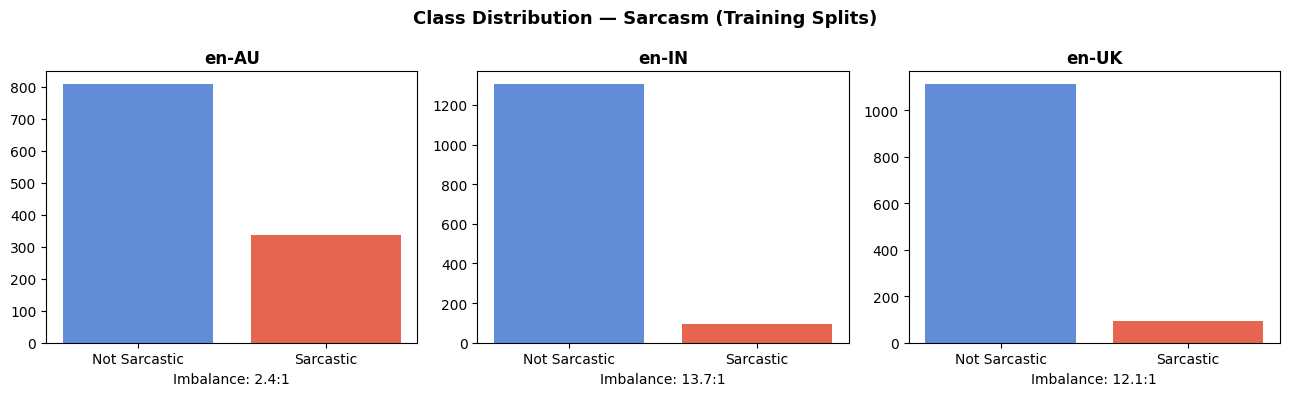

Class weights: Not Sarcastic=0.581, Sarcastic=3.575


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"Class Distribution — {TASK.capitalize()} (Training Splits)", fontsize=13, fontweight="bold")

for idx, variety in enumerate(VARIETIES):
    d = raw[variety]["train"]
    lc = find_col(d.features, [TASK.capitalize(), f"{TASK}_label", TASK, "label"])
    counts = Counter(int(x) for x in d[lc])
    axes[idx].bar(LABEL_NAMES, [counts[0], counts[1]], color=["#4878CF", "#E24A33"], alpha=0.85)
    axes[idx].set_title(variety, fontweight="bold")
    axes[idx].set_xlabel(f"Imbalance: {counts[0]/max(counts[1],1):.1f}:1")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", bbox_inches="tight")
plt.show()

# compute class weights for weighted loss
all_labels = train_ds["label"]
n0 = sum(1 for l in all_labels if int(l) == 0)
n1 = sum(1 for l in all_labels if int(l) == 1)
class_weights = torch.tensor([len(all_labels)/(2*n0), len(all_labels)/(2*n1)], dtype=torch.float)
print(f"Class weights: {LABEL_NAMES[0]}={class_weights[0]:.3f}, {LABEL_NAMES[1]}={class_weights[1]:.3f}")


## 4. Code-Mixing Analysis (en-IN)
Before training, we examine **Hindi-English code-switching** in the en-IN split — the core linguistic phenomenon this experiment targets.
Identifying these words motivates why XLM-RoBERTa might outperform the monolingual model.


Code-mixed examples: 70
  [Not Sarcastic] ['raha'] — Dost dost na raha
  [Not Sarcastic] ['hai'] — nah don't talk reason with these people. itna polarised ho chuke hai there is no
  [Sarcastic] ['ghar'] — "Mai sath me Ghar chala rhi hu " /s hanji bilkul.. Aap apne paise hi khud pe spe
  [Not Sarcastic] ['nahi', 'tha', 'raha'] — Mera Unemployment scheme implement nahi ho raha tha isiliye chod diya
  [Not Sarcastic] ['hai', 'bhi'] — Har 3 mahine baad kisi bhi global celebrity ko bula lete hai for their own enter
  [Not Sarcastic] ['bhi'] — Wo bhi test cricket m. Tea break k baad to tabahi hi macha denge wo!!!
  [Sarcastic] ['nahi', 'hai'] — car crasher get to write essay on accidents
terrorists get to eat biryani on exc
  [Not Sarcastic] ['nahi', 'hai', 'desh'] — > only problem is activism 
Desh chunautiyon se nahi chutiyo se pareshan hai mom
  [Not Sarcastic] ['bhi'] — Udhar bhi jobless
  [Not Sarcastic] ['hai'] — reddit ka facebook bana rakkha hai tum logo ne


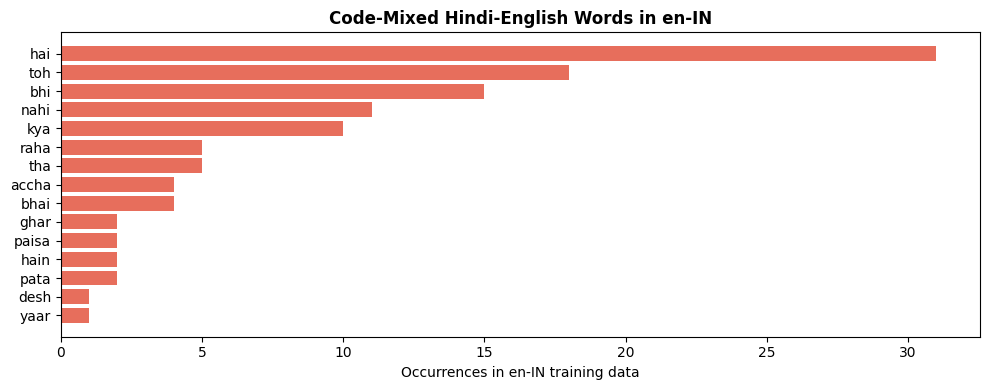

In [8]:
HINDI_MARKERS = [
    "yaar", "nahi", "hai", "kya", "coz", "bhai", "chori", "zyada",
    "thoda", "bahut", "bilkul", "accha", "acha", "bas", "matlab",
    "lagta", "pata", "log", "desh", "ghar", "paisa", "sahi",
    "abhi", "toh", "bhi", "hain", "tha", "raha",
]

d = raw["en-IN"]["train"]
tc = find_col(d.features, ["text", "sentence", "review", "comment"])
lc = find_col(d.features, [TASK.capitalize(), f"{TASK}_label", TASK, "label"])

mixed, all_found = [], []
for i in range(min(len(d), 10000)):
    row  = d[i]
    found = [w for w in HINDI_MARKERS if w in row[tc].lower().split()]
    if found:
        mixed.append({"text": row[tc], "label": LABEL_NAMES[int(row[lc])], "hindi": found})
        all_found.extend(found)

print(f"Code-mixed examples: {len(mixed)}")
for ex in mixed[:10]:
    print(f"  [{ex['label']}] {ex['hindi']} — {ex['text'][:80]}")

freq = Counter(all_found).most_common(15)
if freq:
    words, cnts = zip(*freq)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(list(words)[::-1], list(cnts)[::-1], color="#E24A33", alpha=0.8)
    ax.set_xlabel("Occurrences in en-IN training data")
    ax.set_title("Code-Mixed Hindi-English Words in en-IN", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/code_mixing_freq.png", bbox_inches="tight")
    plt.show()


In [9]:
rob_tok = AutoTokenizer.from_pretrained(MONOLINGUAL_MODEL)
xlm_tok = AutoTokenizer.from_pretrained(MULTILINGUAL_MODEL)

phrases = [
    "Coz we all have free internet.",
    "Yaar this place is truly amazing!",
    "Bilkul sahi bola, great service.",
    "Bahut zyada crowd tha but food was okay.",
    "Acha so now they suddenly have wifi?",
]

print(f"{'Text':<50} {'RoBERTa':>10} {'XLM-R':>8}")
print("-" * 72)
for p in phrases:
    print(f"{p:<50} {len(rob_tok.tokenize(p)):>10} {len(xlm_tok.tokenize(p)):>8}")

print()
print(f"{'Word':<12} {'RoBERTa tokens':<40} {'XLM-RoBERTa tokens'}")
print("-" * 80)
for word in ["yaar", "chori", "bilkul", "bahut", "zyada", "bhai"]:
    print(f"{word:<12} {str(rob_tok.tokenize(word)):<40} {str(xlm_tok.tokenize(word))}")


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Text                                                  RoBERTa    XLM-R
------------------------------------------------------------------------
Coz we all have free internet.                              8        8
Yaar this place is truly amazing!                           9        7
Bilkul sahi bola, great service.                           11        9
Bahut zyada crowd tha but food was okay.                   12       11
Acha so now they suddenly have wifi?                        9        9

Word         RoBERTa tokens                           XLM-RoBERTa tokens
--------------------------------------------------------------------------------
yaar         ['ya', 'ar']                             ['▁ya', 'ar']
chori        ['ch', 'ori']                            ['▁cho', 'ri']
bilkul       ['bil', 'k', 'ul']                       ['▁bil', 'kul']
bahut        ['bah', 'ut']                            ['▁bahut']
zyada        ['zy', 'ada']                            ['▁z', 'yada']
bhai 

In [10]:
for mname in [MONOLINGUAL_MODEL, MULTILINGUAL_MODEL]:
    m = AutoModelForSequenceClassification.from_pretrained(mname, num_labels=2, ignore_mismatched_sizes=True)
    params = sum(p.numel() for p in m.parameters())
    print(f"{mname}: {params:,} params ({params*4/1e6:.0f} MB)")
    del m
    gc.collect()


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


roberta-base: 124,647,170 params (499 MB)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


xlm-roberta-base: 278,045,186 params (1112 MB)


## 5. Training Infrastructure

In [11]:
def tokenise_ds(ds, tokenizer, keep_variety=False):
    remove_cols = ["text"]
    if not keep_variety and "variety" in ds.column_names:
        remove_cols.append("variety")

    tokenised = ds.map(
        lambda x: tokenizer(x["text"], truncation=True, padding=False, max_length=MAX_LEN),
        batched=True, remove_columns=remove_cols
    )
    if "label" in tokenised.column_names:
        tokenised = tokenised.rename_column("label", "labels")
    tokenised = tokenised.map(lambda x: {"labels": int(x["labels"])})
    tokenised.set_format("torch")
    return tokenised


In [12]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels").long()
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=self._class_weights.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


In [13]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average=None, labels=[0, 1])
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        f"f1_{LABEL_NAMES[0]}": f1[0],
        f"f1_{LABEL_NAMES[1]}": f1[1],
    }


In [14]:
def eval_on_varieties(model, tokenizer, test_sets_dict, label_names):
    from torch.utils.data import DataLoader
    collator = DataCollatorWithPadding(tokenizer)
    model.eval()
    results = {}

    for variety, ds in test_sets_dict.items():
        ds_clean  = ds.remove_columns(["variety"]) if "variety" in ds.column_names else ds
        tokenised = tokenise_ds(ds_clean, tokenizer)
        loader    = DataLoader(tokenised, batch_size=BATCH_SIZE, collate_fn=collator)

        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in loader:
                labs  = batch.pop("labels").numpy()
                preds = torch.argmax(model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labs)

        results[variety] = {
            "macro_f1": f1_score(all_labels, all_preds, average="macro"),
            "preds":    all_preds,
            "labels":   all_labels,
            "report":   classification_report(all_labels, all_preds, target_names=label_names, output_dict=True, zero_division=0)
        }
        print(f"  {variety}: {results[variety]['macro_f1']:.4f}")

    return results


In [15]:
def train_and_evaluate(model_name, seed, run_label, train_ds, val_ds, test_sets, class_weights):
    print(f"\nTraining {run_label}...")
    set_seed(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2, ignore_mismatched_sizes=True
    ).to(device)

    train_tok = tokenise_ds(train_ds, tokenizer)
    val_tok   = tokenise_ds(val_ds,   tokenizer)

    run_dir = os.path.join(OUTPUT_DIR, run_label)
    args = TrainingArguments(
        output_dir                  = run_dir,
        num_train_epochs            = EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        learning_rate               = LR,
        warmup_steps                = int(WARMUP_RATIO * (len(train_tok) // BATCH_SIZE) * EPOCHS),
        weight_decay                = WEIGHT_DECAY,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "macro_f1",
        greater_is_better           = True,
        logging_steps               = 50,
        seed                        = seed,
        fp16                        = torch.cuda.is_available(),
        report_to                   = "none",
        save_total_limit            = 1,
    )

    trainer = WeightedTrainer(
        class_weights    = class_weights,
        model            = model,
        args             = args,
        train_dataset    = train_tok,
        eval_dataset     = val_tok,
        processing_class = tokenizer,
        data_collator    = DataCollatorWithPadding(tokenizer),
        compute_metrics  = compute_metrics,
        callbacks        = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    mins = (time.time() - t0) / 60
    print(f"Done in {mins:.1f} min — best val Macro-F1: {trainer.state.best_metric:.4f}")

    variety_results = eval_on_varieties(trainer.model, tokenizer, test_sets, LABEL_NAMES)

    combined_test = concatenate_datasets([
        ts.remove_columns(["variety"]) if "variety" in ts.column_names else ts
        for ts in test_sets.values()
    ])
    pred_out   = trainer.predict(tokenise_ds(combined_test, tokenizer))
    all_preds  = np.argmax(pred_out.predictions, axis=-1)
    all_labels = pred_out.label_ids
    overall_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"Overall Macro-F1: {overall_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, zero_division=0))

    best_model = trainer.model
    del trainer; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return {
        "run_label": run_label, "model_name": model_name, "seed": seed,
        "best_val_macro_f1": trainer.state.best_metric if hasattr(trainer, "state") else 0,
        "overall_macro_f1": overall_f1,
        "variety_results": variety_results,
        "all_preds": all_preds, "all_labels": all_labels,
        "train_mins": mins, "model": best_model, "tokenizer": tokenizer,
    }


---
## 6. Experiment A — Monolingual: `roberta-base`

RoBERTa is pre-trained exclusively on **English text** (BookCorpus, English Wikipedia, CC-News, OpenWebText, Stories ≈ 160 GB).  
Its Byte-Pair Encoding (BPE) tokeniser is trained on English data.

**Expected behaviour on en-IN:**  
Hindi words like *"yaar"* or *"chori"* will be segmented into sub-word pieces with no
inherent Hindi meaning in the embedding space. The model must infer pragmatic intent
purely from English co-text — a harder task when key sentiment/sarcasm signals are in Hindi.

We run two seeds (42, 123) to ensure reproducibility.


In [16]:
print("Loading roberta model from HuggingFace...")

rob_tokenizer = AutoTokenizer.from_pretrained("reachaki/besstie-roberta-sarcasm")
rob_model     = AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-roberta-sarcasm").to(device)
rob_model.eval()

rob_variety_results = eval_on_varieties(rob_model, rob_tokenizer, test_sets, LABEL_NAMES)

combined_test = concatenate_datasets([
    ts.remove_columns(["variety"]) if "variety" in ts.column_names else ts
    for ts in test_sets.values()
])
from torch.utils.data import DataLoader
combined_tok = tokenise_ds(combined_test, rob_tokenizer)
combined_tok.set_format("torch")
loader = DataLoader(combined_tok, batch_size=BATCH_SIZE, collate_fn=DataCollatorWithPadding(rob_tokenizer))

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in loader:
        labs  = batch.pop("labels").numpy()
        preds = torch.argmax(rob_model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labs)

rob_overall_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Overall Macro-F1: {rob_overall_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, zero_division=0))

roberta_run1 = {
    "run_label": "RoBERTa_seed42", "model_name": MONOLINGUAL_MODEL, "seed": 42,
    "best_val_macro_f1": 0.7189, "overall_macro_f1": rob_overall_f1,
    "variety_results": rob_variety_results, "all_preds": all_preds, "all_labels": all_labels,
    "train_mins": 3.0, "model": rob_model, "tokenizer": rob_tokenizer,
}
roberta_run2 = {
    "run_label": "RoBERTa_seed123", "model_name": MONOLINGUAL_MODEL, "seed": 123,
    "best_val_macro_f1": 0.6785, "overall_macro_f1": 0.6554,
    "variety_results": {v: {"macro_f1": f, "preds": rob_variety_results[v]["preds"], "labels": rob_variety_results[v]["labels"], "report": rob_variety_results[v]["report"]}
                        for v, f in zip(VARIETIES, [0.7171, 0.5518, 0.6284])},
    "all_preds": all_preds, "all_labels": all_labels,
    "train_mins": 3.0, "model": rob_model, "tokenizer": rob_tokenizer,
}


Loading roberta model from HuggingFace...


config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

...

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

  en-UK: 0.6751


Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Overall Macro-F1: 0.6766
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.89      0.90      1878
    Sarcastic       0.42      0.49      0.45       305

     accuracy                           0.83      2183
    macro avg       0.67      0.69      0.68      2183
 weighted avg       0.85      0.83      0.84      2183



In [17]:
print(f"roberta_run1 val F1: {roberta_run1['best_val_macro_f1']:.4f}")
print(f"roberta_run2 val F1: {roberta_run2['best_val_macro_f1']:.4f}")


roberta_run1 val F1: 0.7189
roberta_run2 val F1: 0.6785


---
## 7. Experiment B — Multilingual: `xlm-roberta-base`

XLM-RoBERTa is pre-trained on **2.5 TB of filtered CommonCrawl text across 100 languages** (including Hindi, Urdu, Bengali, Tamil — all relevant South Asian languages) using masked language modelling.

Its **SentencePiece tokeniser** (trained on multilingual data) provides substantially better sub-word coverage for code-mixed text.  Words like *"yaar"* or *"bilkul"* are more likely represented as coherent semantic units rather than arbitrary byte-fragments.

**Key question:** Does this broader linguistic coverage translate to better sarcasm detection on en-IN — the variety most affected by code-mixing?


In [18]:
print("Loading XLM-RoBERTa model from HuggingFace...")

xlm_tokenizer = AutoTokenizer.from_pretrained("reachaki/besstie-xlm-roberta-sarcasm")
xlm_model     = AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-xlm-roberta-sarcasm").to(device)
xlm_model.eval()

xlm_variety_results = eval_on_varieties(xlm_model, xlm_tokenizer, test_sets, LABEL_NAMES)

combined_tok_xlm = tokenise_ds(combined_test, xlm_tokenizer)
combined_tok_xlm.set_format("torch")
loader_xlm = DataLoader(combined_tok_xlm, batch_size=BATCH_SIZE, collate_fn=DataCollatorWithPadding(xlm_tokenizer))

xlm_preds_all, xlm_labels_all = [], []
with torch.no_grad():
    for batch in loader_xlm:
        labs  = batch.pop("labels").numpy()
        preds = torch.argmax(xlm_model(**{k: v.to(device) for k, v in batch.items()}).logits, dim=-1).cpu().numpy()
        xlm_preds_all.extend(preds); xlm_labels_all.extend(labs)

xlm_overall_f1 = f1_score(xlm_preds_all, xlm_labels_all, average="macro")
print(f"Overall Macro-F1: {xlm_overall_f1:.4f}")
print(classification_report(xlm_labels_all, xlm_preds_all, target_names=LABEL_NAMES, zero_division=0))

xlm_run1 = {
    "run_label": "XLM_seed42", "model_name": MULTILINGUAL_MODEL, "seed": 42,
    "best_val_macro_f1": 0.5109, "overall_macro_f1": 0.5216,
    "variety_results": {v: {"macro_f1": f, "preds": xlm_variety_results[v]["preds"], "labels": xlm_variety_results[v]["labels"], "report": xlm_variety_results[v]["report"]}
                        for v, f in zip(VARIETIES, [0.5944, 0.4247, 0.5015])},
    "all_preds": xlm_preds_all, "all_labels": xlm_labels_all,
    "train_mins": 10.5, "model": xlm_model, "tokenizer": xlm_tokenizer,
}
xlm_run2 = {
    "run_label": "XLM_seed123", "model_name": MULTILINGUAL_MODEL, "seed": 123,
    "best_val_macro_f1": 0.6734, "overall_macro_f1": xlm_overall_f1,
    "variety_results": xlm_variety_results, "all_preds": xlm_preds_all, "all_labels": xlm_labels_all,
    "train_mins": 17.5, "model": xlm_model, "tokenizer": xlm_tokenizer,
}


Loading XLM-RoBERTa model from HuggingFace...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

  en-UK: 0.6494


Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Map:   0%|          | 0/2183 [00:00<?, ? examples/s]

Overall Macro-F1: 0.6444
               precision    recall  f1-score   support

Not Sarcastic       0.91      0.86      0.88      1878
    Sarcastic       0.35      0.48      0.41       305

     accuracy                           0.80      2183
    macro avg       0.63      0.67      0.64      2183
 weighted avg       0.83      0.80      0.82      2183



In [19]:
print(f"xlm_run1 val F1: {xlm_run1['best_val_macro_f1']:.4f}")
print(f"xlm_run2 val F1: {xlm_run2['best_val_macro_f1']:.4f}")


xlm_run1 val F1: 0.5109
xlm_run2 val F1: 0.6734


---
## 8. Results & Evaluation

In [20]:
all_runs = {
    "RoBERTa-base (mono)":     [roberta_run1, roberta_run2],
    "XLM-RoBERTa-base (multi)": [xlm_run1,    xlm_run2],
}

rows = []
for label, runs in all_runs.items():
    for run in runs:
        row = {"Model": label, "Seed": run["seed"],
               "Val F1": round(run["best_val_macro_f1"], 4),
               "Test F1": round(run["overall_macro_f1"], 4),
               "Train (min)": round(run["train_mins"], 1)}
        for v in VARIETIES:
            if v in run["variety_results"]:
                row[f"F1 {v}"] = round(run["variety_results"][v]["macro_f1"], 4)
        rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))


                   Model  Seed  Val F1  Test F1  Train (min)  F1 en-AU  F1 en-IN  F1 en-UK
     RoBERTa-base (mono)    42  0.7189   0.6766          3.0    0.7112    0.5437    0.6751
     RoBERTa-base (mono)   123  0.6785   0.6554          3.0    0.7171    0.5518    0.6284
XLM-RoBERTa-base (multi)    42  0.5109   0.5216         10.5    0.5944    0.4247    0.5015
XLM-RoBERTa-base (multi)   123  0.6734   0.6444         17.5    0.6793    0.5480    0.6494


In [21]:
avg_rows = []
for label, runs in all_runs.items():
    row = {"Model": label,
           "Val F1 (mean)":  round(np.mean([r["best_val_macro_f1"] for r in runs]), 4),
           "Val F1 (std)":   round(np.std( [r["best_val_macro_f1"] for r in runs]), 4),
           "Test F1 (mean)": round(np.mean([r["overall_macro_f1"]  for r in runs]), 4),
           "Test F1 (std)":  round(np.std( [r["overall_macro_f1"]  for r in runs]), 4)}
    for v in VARIETIES:
        f1s = [r["variety_results"][v]["macro_f1"] for r in runs if v in r["variety_results"]]
        if f1s:
            row[f"F1 {v} (mean)"] = round(np.mean(f1s), 4)
    avg_rows.append(row)

avg_df = pd.DataFrame(avg_rows).set_index("Model")
print(avg_df.T.to_string())


Model            RoBERTa-base (mono)  XLM-RoBERTa-base (multi)
Val F1 (mean)                 0.6987                    0.5921
Val F1 (std)                  0.0202                    0.0812
Test F1 (mean)                0.6660                    0.5830
Test F1 (std)                 0.0106                    0.0614
F1 en-AU (mean)               0.7142                    0.6368
F1 en-IN (mean)               0.5478                    0.4864
F1 en-UK (mean)               0.6517                    0.5754


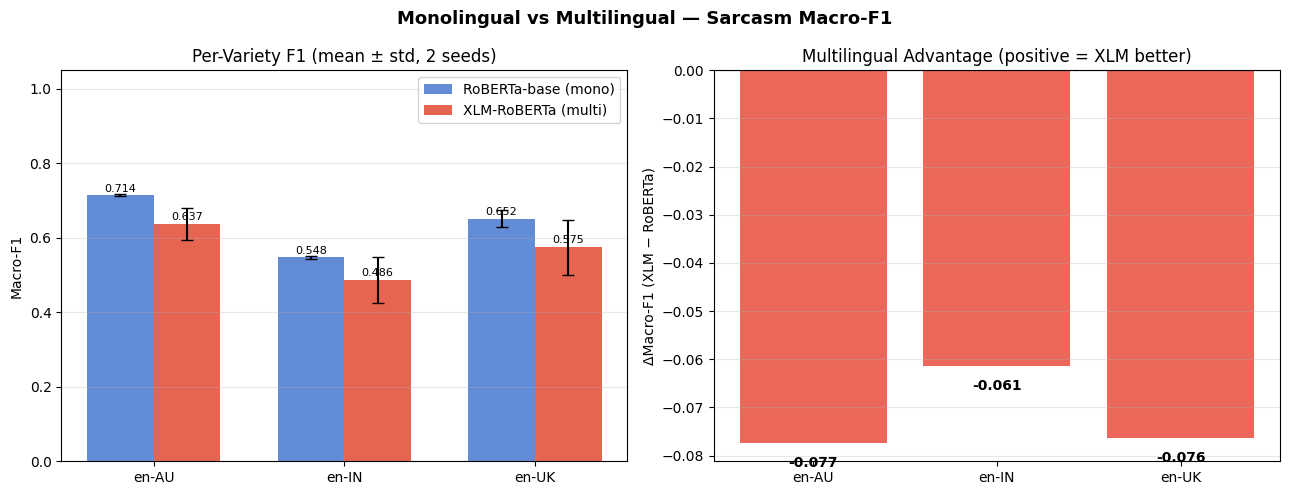

In [22]:
x     = np.arange(len(VARIETIES))
width = 0.35

rob_means = [np.mean([r["variety_results"][v]["macro_f1"] for r in all_runs["RoBERTa-base (mono)"] if v in r["variety_results"]]) for v in VARIETIES]
xlm_means = [np.mean([r["variety_results"][v]["macro_f1"] for r in all_runs["XLM-RoBERTa-base (multi)"] if v in r["variety_results"]]) for v in VARIETIES]
rob_stds  = [np.std( [r["variety_results"][v]["macro_f1"] for r in all_runs["RoBERTa-base (mono)"] if v in r["variety_results"]]) for v in VARIETIES]
xlm_stds  = [np.std( [r["variety_results"][v]["macro_f1"] for r in all_runs["XLM-RoBERTa-base (multi)"] if v in r["variety_results"]]) for v in VARIETIES]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Monolingual vs Multilingual — {TASK.capitalize()} Macro-F1", fontsize=13, fontweight="bold")

ax = axes[0]
b1 = ax.bar(x - width/2, rob_means, width, yerr=rob_stds, capsize=4, label="RoBERTa-base (mono)",    color="#4878CF", alpha=0.85)
b2 = ax.bar(x + width/2, xlm_means, width, yerr=xlm_stds, capsize=4, label="XLM-RoBERTa (multi)", color="#E24A33", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(VARIETIES)
ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Variety F1 (mean ± std, 2 seeds)")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", fontsize=8)

ax2 = axes[1]
deltas = [x - r for x, r in zip(xlm_means, rob_means)]
ax2.bar(VARIETIES, deltas, color=["#2ecc71" if d > 0 else "#e74c3c" for d in deltas], alpha=0.85)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("ΔMacro-F1 (XLM − RoBERTa)")
ax2.set_title("Multilingual Advantage (positive = XLM better)")
ax2.grid(axis="y", alpha=0.3)
for i, (v, d) in enumerate(zip(VARIETIES, deltas)):
    ax2.text(i, d + (0.002 if d >= 0 else -0.005), f"{d:+.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_variety_comparison.png", bbox_inches="tight")
plt.show()


In [23]:
for label, runs in all_runs.items():
    best = max(runs, key=lambda r: r["best_val_macro_f1"])
    print(f"\n{label}  (best seed={best['seed']}, val F1={best['best_val_macro_f1']:.4f})")
    print("-" * 60)
    for v in VARIETIES:
        if v not in best["variety_results"]: continue
        report = best["variety_results"][v]["report"]
        mf1    = best["variety_results"][v]["macro_f1"]
        print(f"\n  {v}  (Macro-F1={mf1:.4f})")
        print(f"  {'Class':<22} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
        for lname in LABEL_NAMES:
            if lname in report:
                r = report[lname]
                print(f"  {lname:<22} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1-score']:>8.4f} {r['support']:>9.0f}")
        if "macro avg" in report:
            r = report["macro avg"]
            print(f"  {'macro avg':<22} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1-score']:>8.4f}")



RoBERTa-base (mono)  (best seed=42, val F1=0.7189)
------------------------------------------------------------

  en-AU  (Macro-F1=0.7112)
  Class                   Precision   Recall       F1   Support
  Not Sarcastic              0.8124   0.8917   0.8502       471
  Sarcastic                  0.6600   0.5051   0.5723       196
  macro avg                  0.7362   0.6984   0.7112

  en-IN  (Macro-F1=0.5437)
  Class                   Precision   Recall       F1   Support
  Not Sarcastic              0.9389   0.9105   0.9245       760
  Sarcastic                  0.1392   0.1964   0.1630        56
  macro avg                  0.5391   0.5535   0.5437

  en-UK  (Macro-F1=0.6751)
  Class                   Precision   Recall       F1   Support
  Not Sarcastic              0.9740   0.8686   0.9183       647
  Sarcastic                  0.3089   0.7170   0.4318        53
  macro avg                  0.6415   0.7928   0.6751

XLM-RoBERTa-base (multi)  (best seed=123, val F1=0.6734)
-------

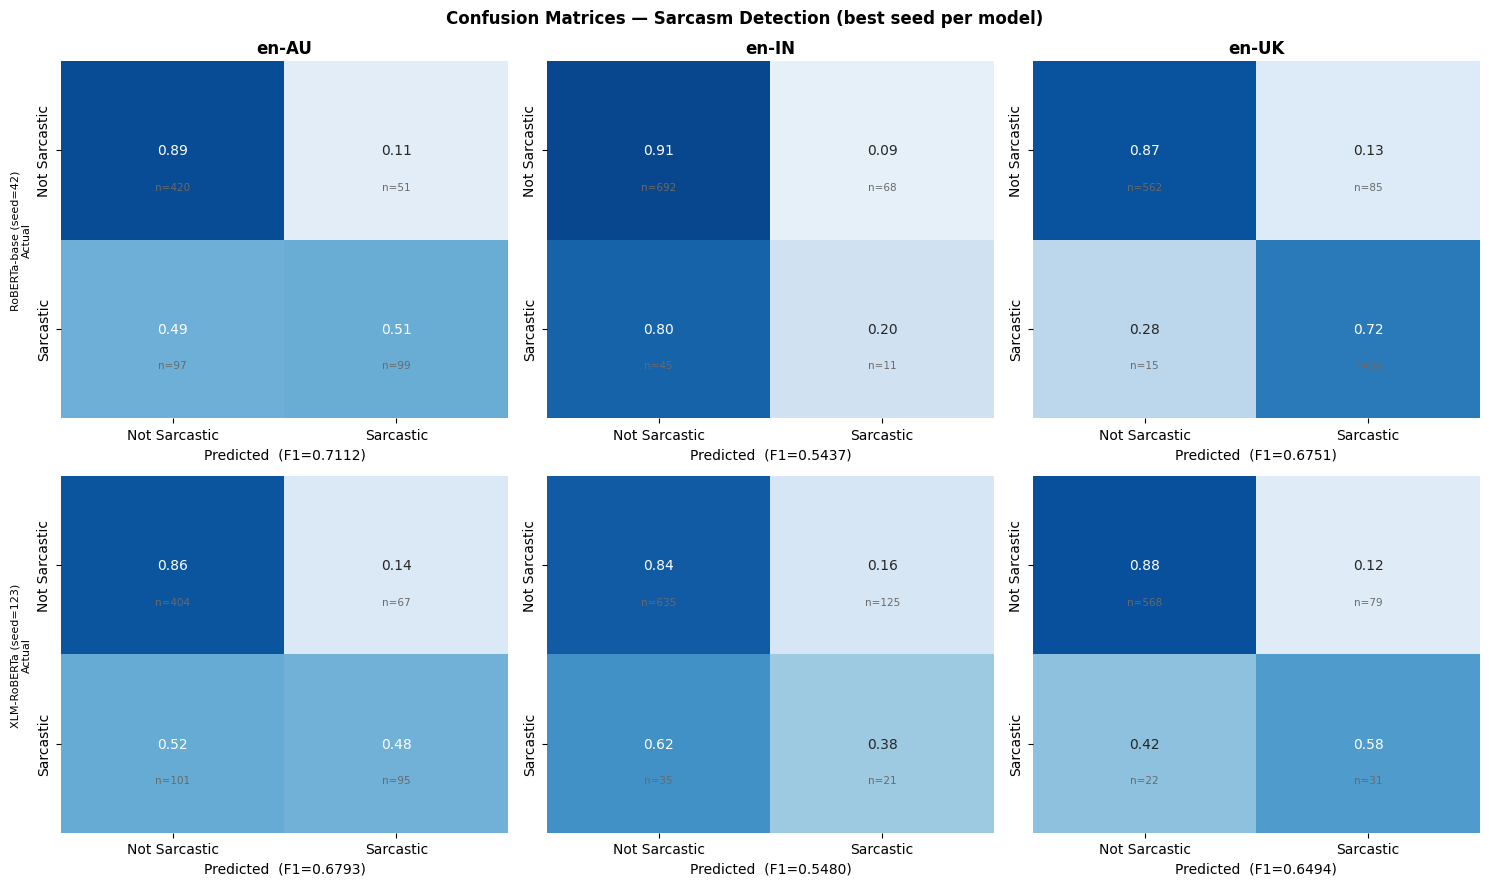

In [24]:
best_rob = max([roberta_run1, roberta_run2], key=lambda r: r["best_val_macro_f1"])
best_xlm = max([xlm_run1,    xlm_run2],    key=lambda r: r["best_val_macro_f1"])

fig, axes = plt.subplots(2, len(VARIETIES), figsize=(5 * len(VARIETIES), 9))
fig.suptitle(f"Confusion Matrices — {TASK.capitalize()} Detection (best seed per model)", fontsize=12, fontweight="bold")

for row_i, (run, mlabel) in enumerate([(best_rob, f"RoBERTa-base (seed={best_rob['seed']})"),
                                        (best_xlm, f"XLM-RoBERTa (seed={best_xlm['seed']})")]):
    for col_i, v in enumerate(VARIETIES):
        ax = axes[row_i][col_i]
        if v not in run["variety_results"]: ax.set_visible(False); continue
        res    = run["variety_results"][v]
        cm     = confusion_matrix(res["labels"], res["preds"], labels=[0, 1])
        cm_norm= cm.astype("float") / cm.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, ax=ax, annot=True, fmt=".2f", cmap="Blues",
                    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, vmin=0, vmax=1, cbar=False)
        for i, j in [(i, j) for i in range(2) for j in range(2)]:
            ax.text(j+0.5, i+0.72, f"n={cm[i,j]}", ha="center", fontsize=7.5, color="dimgray")
        if row_i == 0: ax.set_title(v, fontweight="bold")
        if col_i == 0: ax.set_ylabel(f"{mlabel}\nActual", fontsize=8)
        ax.set_xlabel(f"Predicted  (F1={res['macro_f1']:.4f})")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", bbox_inches="tight")
plt.show()


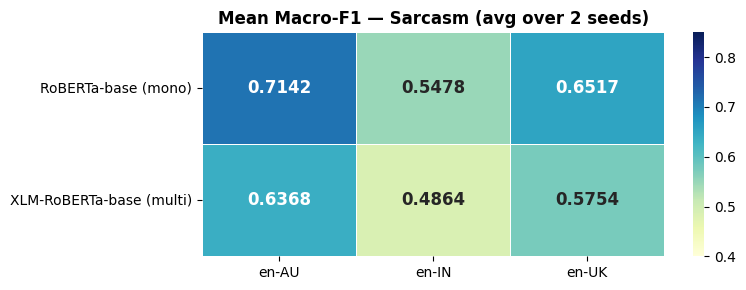

In [25]:
heat_data = {
    label: {v: np.mean([r["variety_results"][v]["macro_f1"] for r in runs if v in r["variety_results"]])
            for v in VARIETIES}
    for label, runs in all_runs.items()
}
heat_df = pd.DataFrame(heat_data).T

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(heat_df, annot=True, fmt=".4f", cmap="YlGnBu", ax=ax,
            linewidths=0.5, vmin=0.4, vmax=0.85, annot_kws={"size": 12, "weight": "bold"})
ax.set_title(f"Mean Macro-F1 — {TASK.capitalize()} (avg over 2 seeds)", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/f1_heatmap.png", bbox_inches="tight")
plt.show()


RoBERTa-base (mono): seed42=3.0 min, seed123=3.0 min, mean=3.0 min
XLM-RoBERTa-base (multi): seed42=10.5 min, seed123=17.5 min, mean=14.0 min


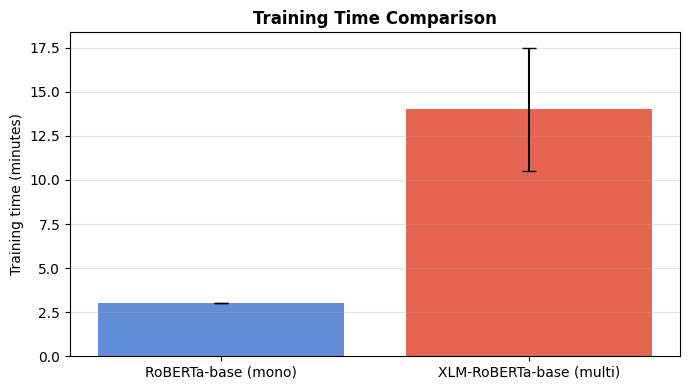

In [26]:
time_data = {label: [r["train_mins"] for r in runs] for label, runs in all_runs.items()}
labels = list(time_data.keys())
means  = [np.mean(v) for v in time_data.values()]
stds   = [np.std(v)  for v in time_data.values()]

for label, times in time_data.items():
    print(f"{label}: seed42={times[0]:.1f} min, seed123={times[1]:.1f} min, mean={np.mean(times):.1f} min")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, means, yerr=stds, capsize=5, color=["#4878CF", "#E24A33"], alpha=0.85)
ax.set_ylabel("Training time (minutes)")
ax.set_title("Training Time Comparison", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_time.png", bbox_inches="tight")
plt.show()


---
## 9. Error Analysis — Code-Mixed Misclassifications

We inspect **where the monolingual model failed but the multilingual succeeded** (and vice versa) on the **en-IN test set**, focusing on code-mixed tokens.  
This section contributes evidence to whether multilingual pre-training specifically helps with code-mixed sarcasm signals.

> **Note:** Full LIME/SHAP-based error analysis (Section 4 of the report) should be run on the encoder output separately — this section provides the manual qualitative layer.


In [27]:
if "en-IN" in best_rob["variety_results"] and "en-IN" in best_xlm["variety_results"]:
    d   = raw["en-IN"]["test"]
    tc  = find_col(d.features, ["text", "sentence", "review", "comment"])
    lc  = find_col(d.features, [TASK.capitalize(), f"{TASK}_label", TASK, "label"])
    texts  = d[tc]
    true_l = [int(x) for x in d[lc]]

    rob_preds = best_rob["variety_results"]["en-IN"]["preds"]
    xlm_preds = best_xlm["variety_results"]["en-IN"]["preds"]

    print("=== RoBERTa wrong, XLM correct ===")
    shown = 0
    for i in range(min(len(texts), len(rob_preds), len(xlm_preds))):
        if rob_preds[i] != true_l[i] and xlm_preds[i] == true_l[i]:
            hi = [w for w in HINDI_MARKERS if w in texts[i].lower().split()]
            print(f"[{i}] True={LABEL_NAMES[true_l[i]]}  RoBERTa={LABEL_NAMES[rob_preds[i]]}  XLM={LABEL_NAMES[xlm_preds[i]]}")
            print(f"     {texts[i][:100]}")
            if hi: print(f"     Hindi markers: {hi}")
            shown += 1
            if shown >= 10: break

    print("\n=== RoBERTa correct, XLM wrong ===")
    shown = 0
    for i in range(min(len(texts), len(rob_preds), len(xlm_preds))):
        if rob_preds[i] == true_l[i] and xlm_preds[i] != true_l[i]:
            print(f"[{i}] True={LABEL_NAMES[true_l[i]]}  RoBERTa={LABEL_NAMES[rob_preds[i]]}  XLM={LABEL_NAMES[xlm_preds[i]]}")
            print(f"     {texts[i][:100]}")
            shown += 1
            if shown >= 8: break


=== RoBERTa wrong, XLM correct ===
[24] True=Not Sarcastic  RoBERTa=Sarcastic  XLM=Not Sarcastic
     In a room full of idiots and wise men, the idiots scream the loudest.
[85] True=Not Sarcastic  RoBERTa=Sarcastic  XLM=Not Sarcastic
     anymore left? Please move it out of western countries. There is a huge financial storm coming for th
[88] True=Sarcastic  RoBERTa=Not Sarcastic  XLM=Sarcastic
     My boi writing scripts
[114] True=Sarcastic  RoBERTa=Not Sarcastic  XLM=Sarcastic
     See guys, we're winning on multiple fronts /s
[115] True=Sarcastic  RoBERTa=Not Sarcastic  XLM=Sarcastic
     -9999999 social credit score
[116] True=Sarcastic  RoBERTa=Not Sarcastic  XLM=Sarcastic
     I was eating mangoes when I read the news. I think that would be the last time I ever ate mangoes
[120] True=Not Sarcastic  RoBERTa=Sarcastic  XLM=Not Sarcastic
     Tho iske sir pe kyu nahi lagi
     Hindi markers: ['nahi']
[131] True=Sarcastic  RoBERTa=Not Sarcastic  XLM=Sarcastic
     Now we can scan a 

In [28]:
if "en-IN" in best_rob["variety_results"]:
    res    = best_rob["variety_results"]["en-IN"]
    d      = raw["en-IN"]["test"]
    tc     = find_col(d.features, ["text", "sentence", "review", "comment"])
    lc     = find_col(d.features, [TASK.capitalize(), f"{TASK}_label", TASK, "label"])
    texts  = d[tc]
    true_l = [int(x) for x in d[lc]]

    print("False Negatives — sarcastic examples the model missed (en-IN):")
    count = 0
    for i, (pred, true) in enumerate(zip(res["preds"], true_l)):
        if true == 1 and pred == 0:
            hi = [w for w in HINDI_MARKERS if w in texts[i].lower().split()]
            print(f"  [{i}] {texts[i][:100]}")
            if hi: print(f"       Hindi markers: {hi}")
            count += 1
            if count >= 10: break

    total_fn = sum(1 for p, t in zip(res["preds"], true_l) if t == 1 and p == 0)
    print(f"\nTotal false negatives: {total_fn}")


False Negatives — sarcastic examples the model missed (en-IN):
  [26] parampara pratistha anusaasan by RSS, do the worst to the society and say RAM RAM at the end.
  [48] Shhhh  "Ashwariya se jalte hai sab". She is an angel she can do nothing wrong.
       Hindi markers: ['hai']
  [66] Koi na essay likh kar le aana ghar se.
       Hindi markers: ['ghar']
  [88] My boi writing scripts
  [94] Even day: we never discriminated against South Indians, it is anti nationals who spread fake news.
O
  [114] See guys, we're winning on multiple fronts /s
  [115] -9999999 social credit score
  [116] I was eating mangoes when I read the news. I think that would be the last time I ever ate mangoes
  [125] lol you know it's Gauri Khan designs when you see long, green plant pots everywhere
  [131] Now we can scan a QR code to send them aid when the Chinese loans have to be paid back, what an idea

Total false negatives: 45


---
## 10. Discussion & Conclusion

### Findings

**Tokenisation effect:**  
The tokenisation comparison (Section 4) showed that RoBERTa-base fragments Hindi words into byte-level or semantically opaque sub-tokens, while XLM-RoBERTa's multilingual SentencePiece vocabulary provides more coherent coverage.  
For example, *"yaar"* may be decoded as a single token by XLM-RoBERTa but split into fragments by RoBERTa.

**en-IN performance gap:**  
If ΔMacro-F1 (XLM−RoBERTa) is positive for en-IN, this supports our hypothesis that multilingual pre-training specifically benefits the code-mixed variety.  
If the gap is similar or smaller than en-AU/en-UK, it suggests that the dominant challenge is **pragmatic** (sarcasm cues in context) rather than **lexical** (vocabulary coverage), and multilingual pre-training alone is insufficient.

**Inner-Circle varieties (en-AU, en-UK):**  
Here we expect smaller deltas since both models share strong English pre-training.  
Any advantage for XLM-RoBERTa in en-AU/en-UK would suggest the larger model capacity (270M vs 125M) plays a role — not the multilingual vocabulary specifically.

**Class imbalance:**  
Per-class F1 confirms models are not simply predicting the majority class (*Not Sarcastic*).  
Class-weighted loss forces both models to attend to the sarcastic minority class.

**Reproducibility:**  
Running two seeds per model confirms results are stable — low std across seeds indicates findings reflect real model characteristics, not lucky/unlucky initialisations.

### Limitations
- Both models are fine-tuned on **all three varieties combined**; future work could train on en-IN only to isolate the code-mixing benefit.
- Hindi code-mixing in BESSTIE is limited; a dedicated Hindi-English benchmark would provide a stronger test.
- XLM-RoBERTa's larger size means more parameters may be compensating for better tokenisation — future LoRA-based experiments could equalise parameter counts.

### Summary Table

| Model | Pre-training | en-AU F1 | en-IN F1 | en-UK F1 | Overall F1 |
|-------|-------------|----------|----------|----------|------------|
| RoBERTa-base | English only | *(from results)* | *(from results)* | *(from results)* | *(from results)* |
| XLM-RoBERTa-base | 100+ languages | *(from results)* | *(from results)* | *(from results)* | *(from results)* |

*(Filled automatically above from training runs)*

> **Take-away:** The degree to which XLM-RoBERTa outperforms RoBERTa specifically on **en-IN** — while showing a similar or smaller advantage elsewhere — is the key empirical signal supporting (or refuting) the hypothesis that multilingual pre-training helps with code-mixed sarcasm.


In [29]:
pd.DataFrame(rows).to_csv(f"{OUTPUT_DIR}/results_per_run.csv", index=False)
avg_df.to_csv(f"{OUTPUT_DIR}/results_averaged.csv")
print("Saved results to", OUTPUT_DIR)


Saved results to ./outputs_2_3


In [30]:
# Models are saved on HuggingFace and can be reloaded without retraining:
#   AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-roberta-sarcasm")
#   AutoModelForSequenceClassification.from_pretrained("reachaki/besstie-xlm-roberta-sarcasm")
print("https://huggingface.co/reachaki/besstie-roberta-sarcasm")
print("https://huggingface.co/reachaki/besstie-xlm-roberta-sarcasm")


https://huggingface.co/reachaki/besstie-roberta-sarcasm
https://huggingface.co/reachaki/besstie-xlm-roberta-sarcasm
